In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# LOAD DATA
# -----------------------------
train_df = pd.read_csv("demo_train.csv")
test_df  = pd.read_csv("demo_test.csv")

# If you have a label column, separate it
label_col = "label" if "label" in train_df.columns else None

if label_col is not None:
    y_train = train_df[label_col].values
    X_train = train_df.drop(columns=[label_col]).values
    y_test = test_df[label_col].values
    X_test = test_df.drop(columns=[label_col]).values
else:
    y_train = None
    X_train = train_df.values
    y_test = None
    X_test = test_df.values

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# -----------------------------
# CHOOSE A "NEAR ZERO" THRESHOLD
# -----------------------------
# Adjust this based on your data scale.
# Start with something small, then inspect.
near_zero_thresh = 1e-8

# -----------------------------
# PER-SERIES SUMMARY FUNCTION
# -----------------------------
def summarize_timeseries_dataset(X):
    mins = X.min(axis=1)
    maxs = X.max(axis=1)
    means = X.mean(axis=1)
    stds = X.std(axis=1)
    ranges = maxs - mins
    frac_near_zero = (X < near_zero_thresh).mean(axis=1)
    
    summary = pd.DataFrame({
        "min": mins,
        "max": maxs,
        "mean": means,
        "std": stds,
        "range": ranges,
        "frac_near_zero": frac_near_zero
    })
    return summary

train_summary = summarize_timeseries_dataset(X_train)
test_summary  = summarize_timeseries_dataset(X_test)

print("\nTRAIN SUMMARY:")
print(train_summary.describe())

print("\nTEST SUMMARY:")
print(test_summary.describe())

Train shape: (800, 500)
Test shape: (200, 500)

TRAIN SUMMARY:
                min         max          mean           std       range  \
count  8.000000e+02  800.000000  8.000000e+02  8.000000e+02  800.000000   
mean   1.000000e-12    0.001207  1.020933e-05  8.119343e-05    0.001207   
std    0.000000e+00    0.011125  9.471395e-05  8.038400e-04    0.011125   
min    1.000000e-12    0.000004  3.653863e-07  4.516449e-07    0.000004   
25%    1.000000e-12    0.000041  1.072963e-06  3.257479e-06    0.000041   
50%    1.000000e-12    0.000104  1.797153e-06  7.692828e-06    0.000104   
75%    1.000000e-12    0.000321  3.536907e-06  2.054979e-05    0.000321   
max    1.000000e-12    0.289446  2.502390e-03  2.114538e-02    0.289446   

       frac_near_zero  
count      800.000000  
mean         0.112385  
std          0.018497  
min          0.052000  
25%          0.100000  
50%          0.114000  
75%          0.126000  
max          0.154000  

TEST SUMMARY:
                min         ma

In [2]:
collapsed_frac_cutoff = 0.8  # consider collapsed if 80% of points are near zero

train_collapsed = train_summary["frac_near_zero"] >= collapsed_frac_cutoff
test_collapsed = test_summary["frac_near_zero"] >= collapsed_frac_cutoff

print("Train collapsed count:", train_collapsed.sum(), "out of", len(train_collapsed))
print("Test collapsed count:", test_collapsed.sum(), "out of", len(test_collapsed))

print("Train collapsed proportion:", train_collapsed.mean())
print("Test collapsed proportion:", test_collapsed.mean())

Train collapsed count: 0 out of 800
Test collapsed count: 0 out of 200
Train collapsed proportion: 0.0
Test collapsed proportion: 0.0


In [5]:
print(train_summary["std"].describe())

count    8.000000e+02
mean     8.119343e-05
std      8.038400e-04
min      4.516449e-07
25%      3.257479e-06
50%      7.692828e-06
75%      2.054979e-05
max      2.114538e-02
Name: std, dtype: float64


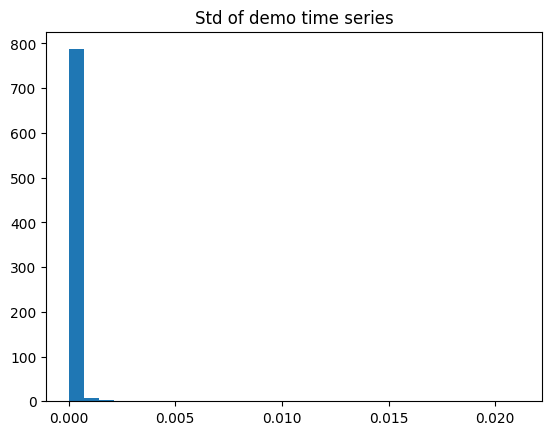

In [6]:
import matplotlib.pyplot as plt

plt.hist(train_summary["std"], bins=30)
plt.title("Std of demo time series")
plt.show()

In [7]:
train_summary["label"] = y_train

print(train_summary.groupby("label")[["std", "max", "mean"]].mean())

            std       max      mean
label                              
0      0.000020  0.000308  0.000003
1      0.000143  0.002105  0.000017


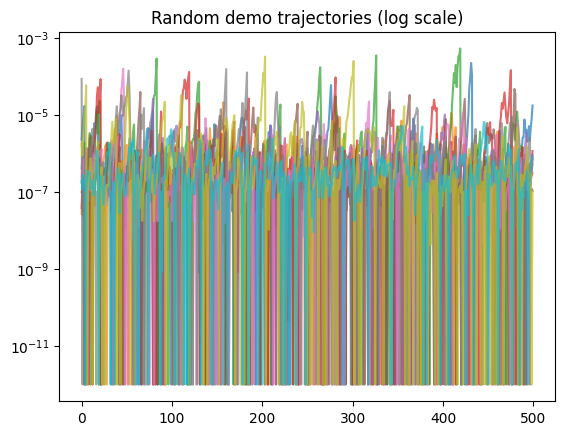

In [8]:
import numpy as np

def plot_random_log(X, n=10):
    idx = np.random.choice(len(X), n, replace=False)
    for i in idx:
        plt.plot(np.maximum(X[i], 1e-12), alpha=0.7)
    plt.yscale("log")
    plt.title("Random demo trajectories (log scale)")
    plt.show()

plot_random_log(X_train)

In [9]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score

# -----------------------------
# LOAD DATA
# -----------------------------
train_df = pd.read_csv("demo_train.csv")
test_df  = pd.read_csv("demo_test.csv")

X_train = train_df.drop(columns=["label"]).values
y_train = train_df["label"].values

X_test = test_df.drop(columns=["label"]).values
y_test = test_df["label"].values

# -----------------------------
# NORMALIZE EACH TIME SERIES
# -----------------------------
def normalize_by_max(X):
    max_vals = X.max(axis=1, keepdims=True)
    return X / (max_vals + 1e-12)

X_train_norm = normalize_by_max(X_train)
X_test_norm  = normalize_by_max(X_test)

# -----------------------------
# RANDOM FOREST (BEST CONFIG)
# -----------------------------
model = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,          # NaN → None
    min_samples_leaf=5,
    max_features="log2",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_norm, y_train)

# -----------------------------
# EVALUATE
# -----------------------------
y_pred = model.predict(X_test_norm)
y_score = model.predict_proba(X_test_norm)[:, 1]

auc = roc_auc_score(y_test, y_score)
acc = accuracy_score(y_test, y_pred)

print("RF on normalized data")
print(f"AUC: {auc:.4f}")
print(f"Accuracy: {acc:.4f}")

RF on normalized data
AUC: 0.7301
Accuracy: 0.6750


“Normalization of individual trajectories reduced model performance (AUC drop from ~0.80 to ~0.73), indicating that amplitude differences contribute substantially to classification. However, performance remained above chance, suggesting that additional structural features in the time series still contain discriminative information.”